In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Housing[1].csv")

# Basic info
print("Columns:", df.columns)
print(df.info())
print(df.head())

Columns: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 

In [ ]:
# Numerical & categorical columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')
Categorical Columns: Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
# Fill numerical with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2611/3444826227.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

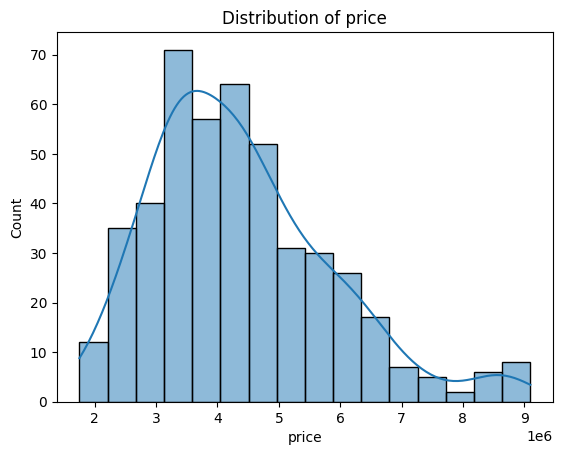

In [ ]:
col = num_cols[0]

plt.figure()
sns.histplot(df[col], kde=True)
plt.title(f"Distribution of {col}")
plt.show()

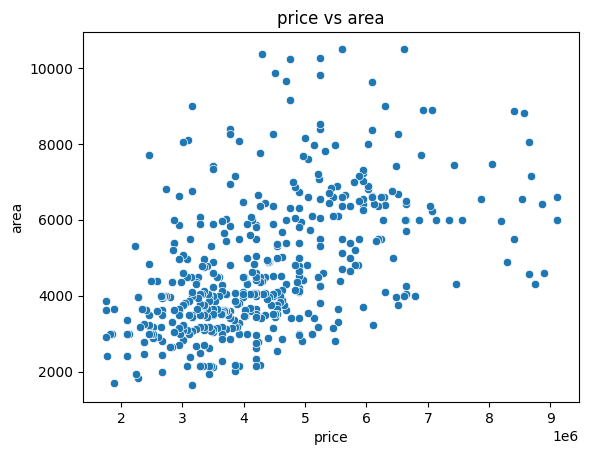

In [ ]:
if len(num_cols) >= 2:
    x = num_cols[0]
    y = num_cols[1]

    plt.figure()
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} vs {y}")
    plt.show()

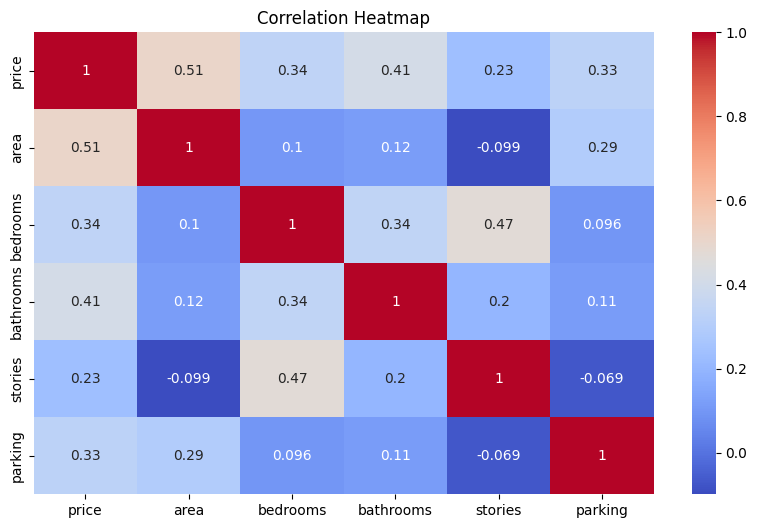

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

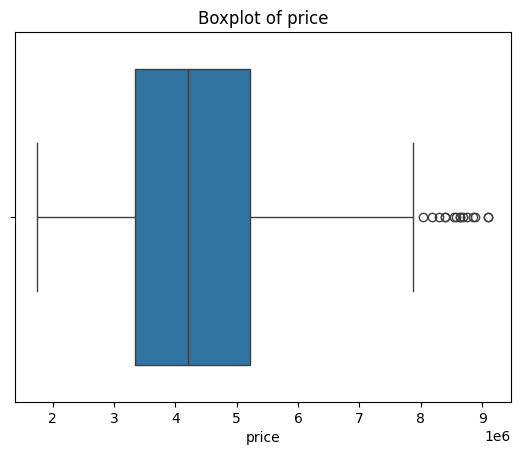

In [ ]:
col = num_cols[0]

plt.figure()
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

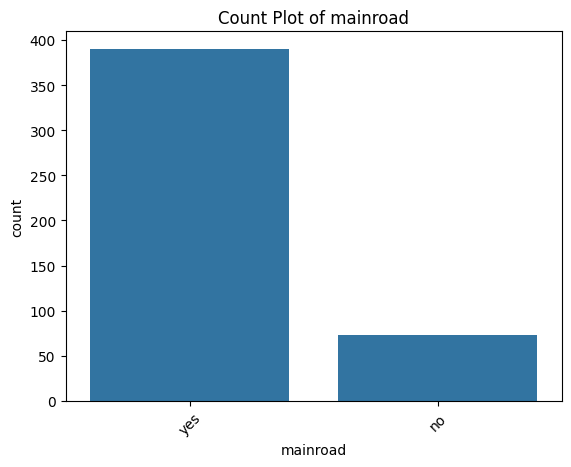

In [ ]:
if len(cat_cols) > 0:
    col = cat_cols[0]

    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
df.to_csv("cleaned_data.csv", index=False)

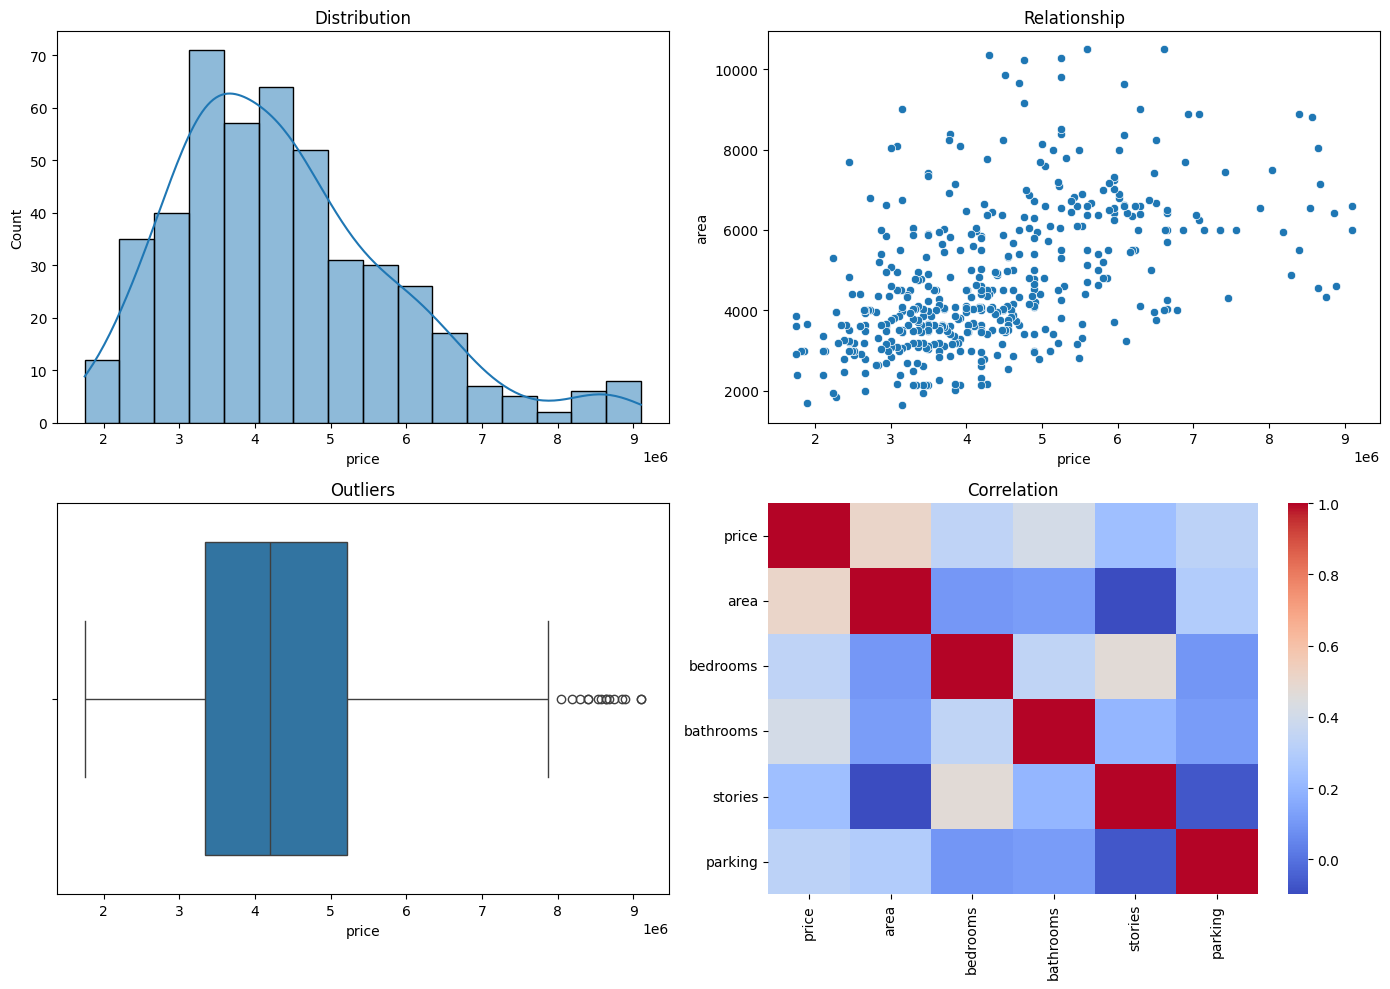

In [ ]:
plt.figure(figsize=(14,10))

# 1. Price Distribution
plt.subplot(2,2,1)
sns.histplot(df[num_cols[0]], kde=True)
plt.title("Distribution")

# 2. Scatter Plot
if len(num_cols) > 1:
    plt.subplot(2,2,2)
    sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]])
    plt.title("Relationship")

# 3. Boxplot
plt.subplot(2,2,3)
sns.boxplot(x=df[num_cols[0]])
plt.title("Outliers")

# 4. Correlation Heatmap
plt.subplot(2,2,4)
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation")

plt.tight_layout()
plt.show()